In [18]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
import pickle
import seaborn as sns
from sklearn.mixture import GaussianMixture

In [2]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(sns.husl_palette(50).as_hex())

# Load data

In [3]:
df_meta_full = pd.read_parquet('./data/df_meta_full.parquet')
print(df_meta_full.shape)
print(df_meta_full.columns)

df_meta_clean = pd.read_parquet('./data/df_meta_clean.parquet')
print(df_meta_clean.shape)
print(df_meta_clean.columns)

(71021, 5)
Index(['animal_id', 'session_id', 'scan_id', 'unit_id', 'depth'], dtype='object')
(45512, 5)
Index(['animal_id', 'session_id', 'scan_id', 'unit_id', 'clusterID'], dtype='object')


In [5]:
resp_chirp_full = np.load('./data/resp_chirp_full.npy')
resp_bar_full = np.load('./data/resp_bar_full.npy')
print(resp_chirp_full.shape)
print(resp_bar_full.shape)

resp_chirp_clean = np.load('./data/resp_chirp_clean.npy')
resp_bar_clean = np.load('./data/resp_bar_clean.npy')
print(resp_chirp_clean.shape)
print(resp_bar_clean.shape)

num_bar_dir = 8

(71021, 251)
(71021, 256)
(45512, 251)
(45512, 256)


# Plot full data set

In [6]:
from matplotlib.colors import LinearSegmentedColormap
colors = ['k', 'midnightblue', 'seagreen', 'y', 'tab:red']  # black -> white -> black
n_bin = 100  # Discretizes the interpolation into bins
cmap_name = 'fs_responses'
cmap = LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bin)

/tmp/ipykernel_54395/285506234.py:52: UserWarning: Adding colorbar to a different Figure <Figure size 300x500 with 2 Axes> than <Figure size 300x500 with 2 Axes> which fig.colorbar is called on.
  cbar = fig.colorbar(im, cax=axins, orientation='vertical')#, ticks=[0, 10])


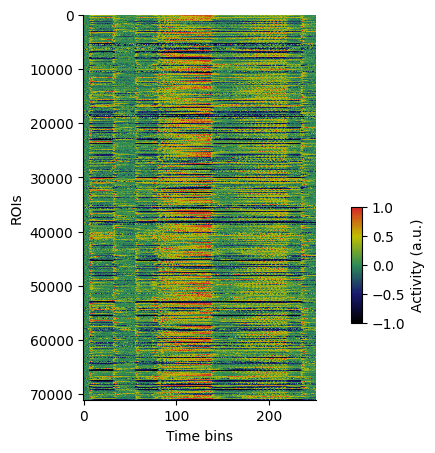

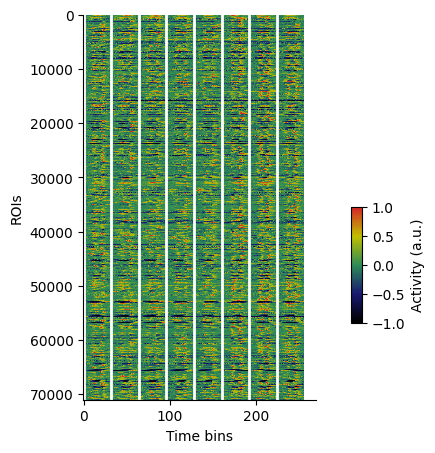

In [11]:
# Generate random indices once to apply to both
np.random.seed(100)
random_indices = np.random.permutation(resp_chirp_full.shape[0])

# Plot responses to chirp stimulus
X = resp_chirp_full
fig, ax = plt.subplots(1, 1, figsize=(3,5))
X_shuffled = X[random_indices]  # Use same ordering for both
vminmax = np.max(np.abs([X_shuffled.min(), X_shuffled.max()]))
ax.set_ylabel('ROIs')
ax.set_xlabel('Time bins')
im = ax.imshow(X_shuffled, aspect='auto', cmap=cmap, interpolation='none')
sns.despine()
# Colorbar
axins = inset_axes(
    ax,
    width="5%",  # width: 50% of parent_bbox width
    height="30%",  # height: 5%
    loc="lower right",
    bbox_to_anchor=(.2, .2, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
axins.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(im, cax=axins, orientation='vertical')#, ticks=[0, 10])
#cbar.ax.tick_params(labelsize=5)
cbar.set_label('Activity (a.u.)')
fig.patch.set_facecolor('white')

# Plot responses to moving bar
X = resp_bar_full
fig, ax = plt.subplots(1, 1, figsize=(3,5))
X_shuffled = X[random_indices]  # Use same ordering for both
vminmax = np.max(np.abs([X_shuffled.min(), X_shuffled.max()]))
ax.set_ylabel('ROIs')
ax.set_xlabel('Time bins')
ax.imshow(X_shuffled, aspect='auto', cmap=cmap, interpolation='none')
for dir_pos in np.linspace(0,resp_bar_full.shape[1], num_bar_dir+1):
    ax.axvline(x=dir_pos, color='white', linewidth=2, linestyle='-')
sns.despine()
# Colorbar
axins = inset_axes(
    ax,
    width="5%",  # width: 50% of parent_bbox width
    height="30%",  # height: 5%
    loc="lower right",
    bbox_to_anchor=(.2, .2, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
axins.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(im, cax=axins, orientation='vertical')#, ticks=[0, 10])
#cbar.ax.tick_params(labelsize=5)
cbar.set_label('Activity (a.u.)')
fig.patch.set_facecolor('white')

# Plot clean data set

In [12]:
# Use meta data df to get excluded responses
merged = df_meta_full.merge(
    df_meta_clean[['animal_id', 'session_id', 'scan_id', 'unit_id']], 
    on=['animal_id', 'session_id', 'scan_id', 'unit_id'],
    how='left',
    indicator=True
)
excluded_indices = merged[merged['_merge'] == 'left_only'].index
excluded_indices_proporion = excluded_indices.shape[0]/df_meta_full.shape[0]

# Check if number of excluded responses matches
assert excluded_indices.shape[0]==df_meta_full.shape[0]-df_meta_clean.shape[0]

# Get excluded responses
resp_chirp_excluded = resp_chirp_full[excluded_indices]
resp_bar_excluded = resp_bar_full[excluded_indices]

# Shuffle responses for plotting
np.random.seed(100)
random_indices = np.random.permutation(resp_chirp_excluded.shape[0])
resp_chirp_excluded_shuffled = resp_chirp_excluded[random_indices]
resp_bar_excluded_shuffled = resp_bar_excluded[random_indices]

In [13]:
# Sort response matrix by cluster ID
sort_indices = np.argsort(df_meta_clean['clusterID'].values)
# Find cluster transition points
cluster_ids_sorted = df_meta_clean['clusterID'].values[sort_indices]
cluster_transitions = np.where(np.diff(cluster_ids_sorted) != 0)[0] + 1

resp_chirp_clean_sorted = resp_chirp_clean[sort_indices]
resp_bar_clean_sorted = resp_bar_clean[sort_indices]

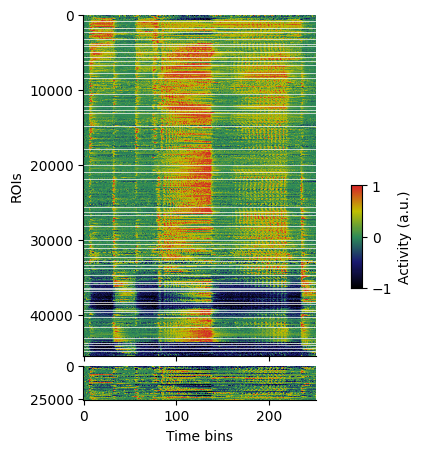

In [14]:
fig, axs = plt.subplots(2, 1, figsize=(3,5), sharex=True, gridspec_kw={"height_ratios":[1, .1], "hspace": 0.05})

ax = axs[0]
vminmax = np.max(np.abs([resp_chirp_clean_sorted.min(), resp_chirp_clean_sorted.max()]))
im = ax.imshow(resp_chirp_clean_sorted, aspect='auto', cmap=cmap, interpolation='none')
# Draw white lines at cluster transitions
for transition in cluster_transitions:
    ax.axhline(y=transition - 0.5, color='white', linewidth=.5, linestyle='-')
ax.set_ylabel('ROIs')
# Colorbar
axins = inset_axes(
    ax,
    width="5%",  # width: 50% of parent_bbox width
    height="30%",  # height: 5%
    loc="lower right",
    bbox_to_anchor=(.2, .2, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
axins.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(im, cax=axins, orientation='vertical')#, ticks=[0, 10])
#cbar.ax.tick_params(labelsize=5)
cbar.set_label('Activity (a.u.)')

ax = axs[1]
vminmax = np.max(np.abs([resp_chirp_excluded_shuffled.min(), resp_chirp_excluded_shuffled.max()]))
ax.imshow(resp_chirp_excluded_shuffled, aspect='auto', cmap=cmap, interpolation='none')
ax.set_ylabel(' ')
ax.set_xlabel('Time bins')

sns.despine()
fig.patch.set_facecolor('white')

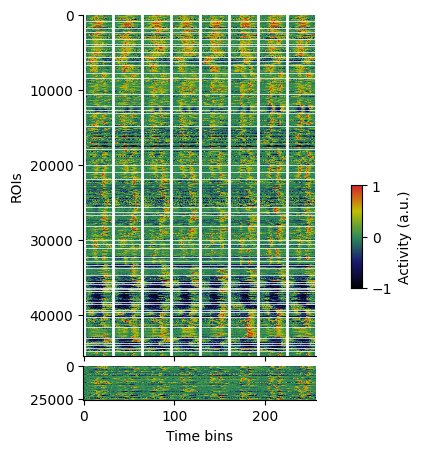

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(3,5), sharex=True, gridspec_kw={"height_ratios":[1, .1], "hspace": 0.05})

ax = axs[0]
vminmax = np.max(np.abs([resp_bar_clean_sorted.min(), resp_bar_clean_sorted.max()]))
im = ax.imshow(resp_bar_clean_sorted, aspect='auto', cmap=cmap, interpolation='none')
# Draw white lines at cluster transitions
for transition in cluster_transitions:
    ax.axhline(y=transition - 0.5, color='white', linewidth=.5, linestyle='-')
for dir_pos in np.linspace(0,resp_bar_full.shape[1], num_bar_dir+1):
    ax.axvline(x=dir_pos, color='white', linewidth=2, linestyle='-')
ax.set_ylabel('ROIs')
# Colorbar
axins = inset_axes(
    ax,
    width="5%",  # width: 50% of parent_bbox width
    height="30%",  # height: 5%
    loc="lower right",
    bbox_to_anchor=(.2, .2, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0,
)
axins.xaxis.set_ticks_position("bottom")
cbar = fig.colorbar(im, cax=axins, orientation='vertical')#, ticks=[0, 10])
#cbar.ax.tick_params(labelsize=5)
cbar.set_label('Activity (a.u.)')

ax = axs[1]
vminmax = np.max(np.abs([resp_bar_excluded_shuffled.min(), resp_bar_excluded_shuffled.max()]))
ax.imshow(resp_bar_excluded_shuffled, aspect='auto', cmap=cmap, interpolation='none')
ax.set_ylabel(' ')
ax.set_xlabel('Time bins')

sns.despine()
fig.patch.set_facecolor('white')

# Cluster cleaning example response types

In [19]:
# GMM uses Expectation-Maximization, which even with a fixed random_state for initialization can converge to slightly different solutions. 
gmm = GaussianMixture(n_components=20, covariance_type='diag', random_state=100)
gmm.fit(resp_chirp_excluded)
labels = gmm.predict(resp_chirp_excluded)
probability = gmm.predict_proba(resp_chirp_excluded)

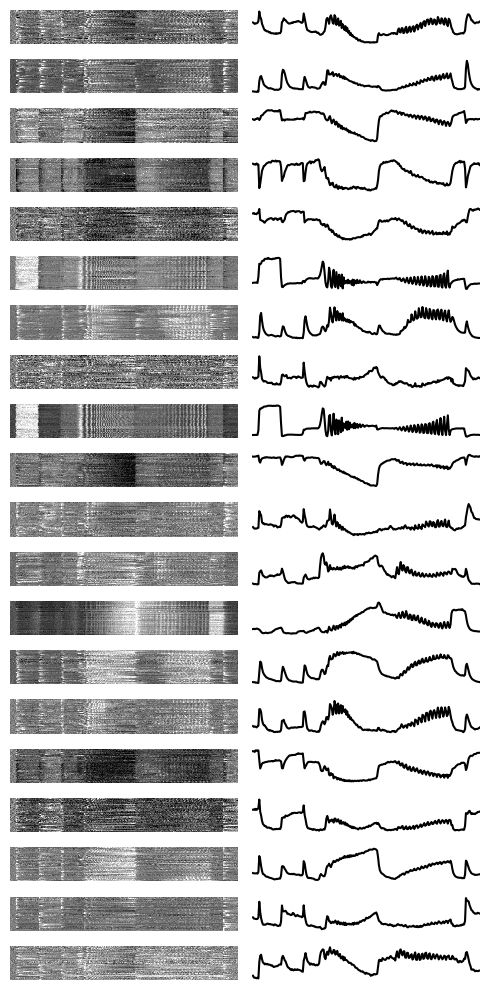

In [26]:
fig, axs = plt.subplots(n_clusters, 2, figsize=(5,10), sharex=True)

for i in range(n_clusters):
    ax=axs[i,0]
    ax.imshow(resp_chirp_excluded[np.where(labels==i)[0],:], 
              aspect='auto', 
              cmap='gray', 
              interpolation='none')
    ax.axes.set_axis_off()

    ax=axs[i,1]
    ax.plot(np.mean(resp_chirp_excluded[np.where(labels==i)[0],:], axis=0), 'k')
    ax.axes.set_axis_off()
    
fig.tight_layout()

fig.patch.set_facecolor('white')